<a href="https://colab.research.google.com/github/alcj17/PucRio/blob/main/mvp_machine_learning_analytics_lacerda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MVP de  Machine Learning & Analytics**

# Sprint:  Machine Learning & Analytics (40530010056_20240_02)

## Profs. Tatiana Escovedo e Hélio Lopes

#### Por: Antonio Lacerda de Castro Junior


# Introdução

Este MVP é apresentado como entrega da sprint de Machine Learning & Analytics.

# Objetivo

Trabalhar desde a definição do problema até a etapa de pré-processamento de dados, conforme esquema visto na disciplina.

Mostrando em cada etapa o que foi feito

## 1. Definição do Problema

  A companhia busca entender a distribuição de pedidos por data e seus respectivos status a partir de 01/06/2024, considerando todos os Centros de Distribuição. Neste estudo inicial, o foco é analisar a quantidade de pedidos e seu comportamento ao longo do tempo, sem a necessidade de detalhar os pontos de saída das entregas. O objetivo principal é prever, a curto prazo (dentro de um período de 8 meses), se o volume de pedidos apresenta tendência de crescimento, estabilidade ou declínio, bem como analisar o desempenho logístico com base nos SLA de entrega associados aos status dos pedidos.

  O dataset contém uma fração representativa de dados diários de pedidos, incluindo informações como data de criação, status do pedido, tipo de entrega, prazo máximo de entrega, e destino. Os atributos disponíveis permitem mapear, ao longo de uma linha do tempo, mudanças no status dos pedidos, identificar gargalos e prever a volumetria futura. Além disso, há potencial para prever tendências relacionadas ao desempenho logístico em diferentes regiões e categorias de entrega. Para este MVP, utilizaremos uma amostra de 99.999 registros, que servirá como base para treinar modelos de classificação e regressão.

## 2. Atributos
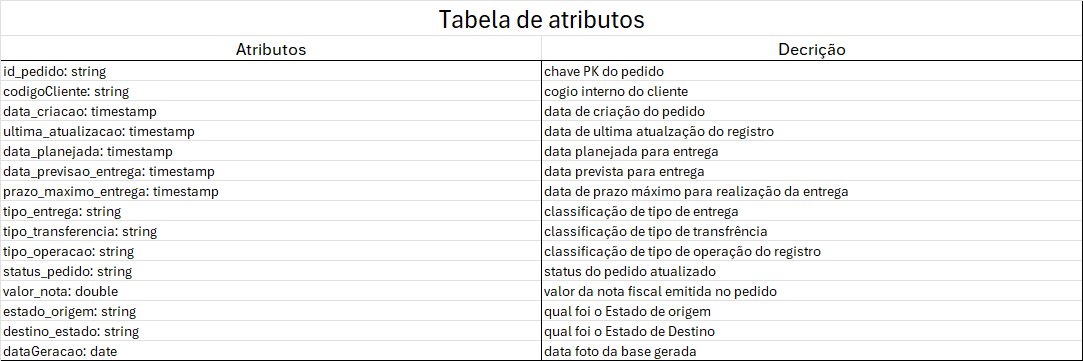


## Etapas do Projeto

## 3. Configurando o ambiente
primeiro passo é instalar o pyspark para poder realizar processamentos mais rápidos

In [1]:
# Instalando o pyspark
!pip install -q pyspark

 Após a instalação do pyspark o drive será montado no google drive ond eestão as bases que serão usadas no projeto.

## 3.1 Preparando o ambiente spark
abaixo vamos criar uma sessão do spark para poder concentrar recursos e usar melhoro ambiente

In [2]:
# Importar a biblioteca drive
import pyspark
import pandas as pd
from google.colab import drive

from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.functions import col,to_date,date_format,year,month,dayofmonth
from pyspark.sql import SparkSession

# Inicializa a sessão Spark
spark = SparkSession.builder \
    .appName("Importando Bases") \
    .getOrCreate()

## 3.2 Montando a conexão com o google drive

Aqui vamos buscar as bases no google drive realizando a montagem através da biblioteca já carregada anteriormente - google.colab

In [3]:
# Montar o Google Drive
drive.mount('/content/drive')

# Definindo caminho da base de Pedidos
file_path = '/content/drive/My Drive/mvp/bases/base_pedido_com_tipos.csv'

# o link acima é de acesso público , abaixo segue link original
# base pedidos
# https://drive.google.com/drive/folders/1BC-uXOhjgJoPpJf8YQ15rEZqUDIVY5IJ?usp=sharing

# base pedidos com tipos original:
# link: https://drive.google.com/file/d/1Ru8kVfnHc3BZRSrXargjW8VCZec6-L5Q/view?usp=drive_link

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3.3 Lendo e carregando os dados em um dataframe pyspark

In [4]:
# Carregar o arquivo CSV em um DataFrame PySpark
df_pedidos = spark.read.csv(file_path, header=True, inferSchema=True, sep=";")

## 3.4 Verificando a volumetria da análise

In [5]:
# Exibir as primeiras linhas do resultado
df_pedidos = df_pedidos.filter(col("data_criacao")>="2024-06-01")

# analisando qual a volumteria que tem na massa de análise
print("total> "+str(df_pedidos.count()))

total> 2805959


## 3.5 Verificando os tipos de dados através do schema

In [6]:
df_pedidos.printSchema()

root
 |-- id_pedido: string (nullable = true)
 |-- codigoCliente: string (nullable = true)
 |-- data_criacao: timestamp (nullable = true)
 |-- ultima_atualizacao: timestamp (nullable = true)
 |-- data_planejada: timestamp (nullable = true)
 |-- data_previsao_entrega: timestamp (nullable = true)
 |-- prazo_maximo_entrega: timestamp (nullable = true)
 |-- tipo_entrega: string (nullable = true)
 |-- tipo_transferencia: string (nullable = true)
 |-- tipo_operacao: string (nullable = true)
 |-- status_pedido: string (nullable = true)
 |-- valor_nota: double (nullable = true)
 |-- estado_origem: string (nullable = true)
 |-- destino_estado: string (nullable = true)
 |-- dataGeracao: date (nullable = true)



Reduzindo a massa para entender os dados contidos para análise com base na coluna de data que vou usar na minha análise.

In [7]:
# Converte o campo data_criacao para o tipo date
df_pedidos = df_pedidos.withColumn("data_criacao", to_date("data_criacao"))

df_pedidos.show(2, truncate=False)

+------------------------+------------------------+------------+-----------------------+--------------+---------------------+--------------------+------------+------------------+-------------+-------------+----------+-------------+--------------+-----------+
|id_pedido               |codigoCliente           |data_criacao|ultima_atualizacao     |data_planejada|data_previsao_entrega|prazo_maximo_entrega|tipo_entrega|tipo_transferencia|tipo_operacao|status_pedido|valor_nota|estado_origem|destino_estado|dataGeracao|
+------------------------+------------------------+------------+-----------------------+--------------+---------------------+--------------------+------------+------------------+-------------+-------------+----------+-------------+--------------+-----------+
|66cb80205f49c60bf7fedc68|60f84d6aa1a5670001ead25b|2024-08-25  |2024-08-25 19:04:14.94 |NULL          |NULL                 |NULL                |NORMAL      |NULL              |DIRETO       |CANCELADA    |1932.53   |RJ    

## 3.6 Convertendo para o Pandas

In [8]:
# verificando se o filtro foi eficiente mostrando as datas mínima e máxima dentro do dataframe
min_date = df_pedidos.agg(F.min("data_criacao")).collect()[0][0]
max_date = df_pedidos.agg(F.max("data_criacao")).collect()[0][0]

print("Data mínima:", min_date)
print("Data máxima:", max_date)

# particionando o dataframe para a conversão ser mais rápida
df_Spark = df_pedidos.repartition(50)

# criando campos de Ano, mês e dia como Integer para análises focadas nas datas
df_Spark = df_Spark.withColumn("Ano", F.year("data_criacao"))
df_Spark = df_Spark.withColumn("Mes", F.month("data_criacao"))
df_Spark = df_Spark.withColumn("Dia", F.dayofmonth("data_criacao"))

Data mínima: 2024-06-01
Data máxima: 2024-09-14


In [9]:
# convertendo para o pandas usando o Arrow por conta de performance.
spark.conf.set("spark.sql.execution.arrow.enabled", "true")

# convertendo para o Pandas
df_pandas = df_Spark.toPandas()

## 3.7 Analisando meus Dados e metadados com o Pandas

In [10]:
# verificando o uso de memória por coluna em sua massa bruta
memory_usage_per_column = df_pandas.memory_usage(deep=True)
print(memory_usage_per_column)

# analisando minhas colunas e seus tipos
df_pandas.info()

Index                          128
id_pedido                227282679
codigoCliente            227282679
data_criacao             112238360
ultima_atualizacao        22447672
data_planejada            22447672
data_previsao_entrega     22447672
prazo_maximo_entrega      22447672
tipo_entrega             178041297
tipo_transferencia       201786034
tipo_operacao            176719560
status_pedido            183185519
valor_nota                22447672
estado_origem            165551581
destino_estado           165551581
dataGeracao              112238360
Ano                       11223836
Mes                       11223836
Dia                       11223836
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2805959 entries, 0 to 2805958
Data columns (total 18 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   id_pedido              object        
 1   codigoCliente          object        
 2   data_criacao           object   

## 4 Preparação dos Dados:
Reduzir o uso de memória e ajustar os tipos de dados para iniciar a análise.

1 - Os campos de datas estão como Object,
 então preciso converter para date mesmo que seu dados já estejam em formato de data

In [12]:
# convertendo as colunas data que estão como object
df_pandas['data_criacao'] = pd.to_datetime(df_pandas['data_criacao'])
df_pandas['dataGeracao'] = pd.to_datetime(df_pandas['dataGeracao'])

2 - Agora vamos converter todas as colunas que estão como Object e não pertencem a outro tipo de dado

In [13]:
# usando um for para percorrer todas as colunas e ajustar os tipos para Category e assim economizar memória
for col in df_pandas.select_dtypes(include='object').columns:
    df_pandas[col] = df_pandas[col].astype('category')

# as colunas id_pedido e identificacaoCliente ficaram como object pois serão descartadas em breve
# convertendo de volta as colunas que serão expurgadas da análise
df_pandas['id_pedido'] = df_pandas['id_pedido'].astype('object')

3 - Agora vamos observar o ganho de perfomance para realização da análise.

In [14]:
memory_usage_per_column = df_pandas.memory_usage(deep=True)
print(memory_usage_per_column)

df_pandas.info()

# observe no resultado e compare com o outro de verificação de uso de memória acima
# e vai ver que houveram grandes ganhos inclusive no uso de memória no geral que caiu quase 50%

Index                          128
id_pedido                227282679
codigoCliente              6065705
data_criacao              22447672
ultima_atualizacao        22447672
data_planejada            22447672
data_previsao_entrega     22447672
prazo_maximo_entrega      22447672
tipo_entrega               2806195
tipo_transferencia         2806855
tipo_operacao              2806514
status_pedido              2807946
valor_nota                22447672
estado_origem              2807931
destino_estado             2808624
dataGeracao               22447672
Ano                       11223836
Mes                       11223836
Dia                       11223836
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2805959 entries, 0 to 2805958
Data columns (total 18 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   id_pedido              object        
 1   codigoCliente          category      
 2   data_criacao           datetime6

In [15]:
# volumetria por colunas
df_pandas.count()


,0
id_pedido,2805959
codigoCliente,2805959
data_criacao,2805959
ultima_atualizacao,2805959
data_planejada,838996
data_previsao_entrega,21568
prazo_maximo_entrega,2594784
tipo_entrega,2805959
tipo_transferencia,2590960
tipo_operacao,2805959


In [16]:
# ordenando pela data de criação do pedido
df_pandas = df_pandas.sort_values(by='data_criacao')

## 4.1 Preparação e Transformação das colunas vazias ou nulas

In [17]:
# Primeria lista de colunas para ajustes
colunas_para_ajustar = ['status_pedido']

# Adicionar a nova categoria 'SEM STATUS' em cada coluna, se ela for categórica
for coluna in colunas_para_ajustar:
    # Se a coluna for categórica, adicionar a categoria 'SEM STATUS' se ainda não estiver presente
    if df_pandas[coluna].dtype.name == 'category':
        if 'SEM STATUS' not in df_pandas[coluna].cat.categories:
            df_pandas[coluna] = df_pandas[coluna].cat.add_categories('SEM STATUS')

    # Substituindo valores nulos ou vazios por 'SEM STATUS'
    df_pandas[coluna] = df_pandas[coluna].replace('', None)
    df_pandas[coluna] = df_pandas[coluna].fillna('SEM STATUS')

# Segunda lista de colunas para ajustes
colunas_para_ajustar = ['tipo_entrega','tipo_transferencia','tipo_operacao','estado_origem','destino_estado']

# Adicionar a nova categoria 'SEM STATUS' em cada coluna, se ela for categórica
for coluna in colunas_para_ajustar:
    # Se a coluna for categórica, adicionar a categoria 'NÃO INFORMADO' se ainda não estiver presente
    if df_pandas[coluna].dtype.name == 'category':
        if 'NÃO INFORMADO' not in df_pandas[coluna].cat.categories:
            df_pandas[coluna] = df_pandas[coluna].cat.add_categories('NÃO INFORMADO')

    # Substituir valores nulos ou vazios por 'NÃO INFORMADO'
    df_pandas[coluna] = df_pandas[coluna].replace('', None)
    df_pandas[coluna] = df_pandas[coluna].fillna('NÃO INFORMADO')

# Lista de colunas de data que precisam ser preenchidas
colunas_data = ['prazo_maximo_entrega', 'data_previsao_entrega', 'data_planejada', 'ultima_atualizacao']

# Preencher as colunas de data com os valores da coluna 'Data_Criacao' onde houver valores nulos
for coluna in colunas_data:
    df_pandas[coluna] = df_pandas[coluna].fillna(df_pandas['data_criacao'])

# Ajustando todos os valores da coluna 'Concluido' para letras maiúsculas
df_pandas['tipo_entrega'] = df_pandas['tipo_entrega'].str.upper()
df_pandas['tipo_transferencia'] = df_pandas['tipo_transferencia'].str.upper()
df_pandas['tipo_operacao'] = df_pandas['tipo_operacao'].str.upper()
df_pandas['status_pedido'] = df_pandas['status_pedido'].str.upper()
df_pandas['estado_origem'] = df_pandas['estado_origem'].str.upper()
df_pandas['destino_estado'] = df_pandas['destino_estado'].str.upper()

# Preencher valores NaN com 0 o campo Ordem
df_pandas['valor_nota'] = df_pandas['valor_nota'].fillna(0)

# Verificar o dataframe
display(df_pandas)


,id_pedido,codigoCliente,data_criacao,ultima_atualizacao,data_planejada,data_previsao_entrega,prazo_maximo_entrega,tipo_entrega,tipo_transferencia,tipo_operacao,status_pedido,valor_nota,estado_origem,destino_estado,dataGeracao,Ano,Mes,Dia
630306,665b9478e50882735d009aa0,647742298f1b04195dbcdce8,2024-06-01,2024-06-05 19:18:12.199,2024-06-10 03:00:00.000,2024-06-01,2024-06-11 03:00:00,NORMAL,TRANSFERENCIA_UX,ENVVIAS,ENTREGUE,199.00,MG,RJ,2024-09-14,2024,6,1
124082,665b7ecd2c39a669cb6dc6a7,60f84d6aa1a5670001ead25b,2024-06-01,2024-09-01 05:15:00.724,2024-06-01 00:00:00.000,2024-06-01,2024-06-04 03:00:00,NORMAL,TRANSFERENCIA_DIRETA,DIRETO,EM_FIRST_MILE,284.08,RJ,RJ,2024-09-14,2024,6,1
2479688,665b25b80ad1453a22e46f8f,60edad72a1a5670001e69aa9,2024-06-01,2024-06-04 00:52:12.460,2024-06-01 00:00:00.000,2024-06-01,2024-06-03 03:00:00,NORMAL,TRANSFERENCIA_DIRETA,DIRETO,ENTREGUE,2848.10,RN,RN,2024-09-14,2024,6,1
1692339,665b47e80a49d72076cb0a90,6297aaa3c4be3a000113ec3d,2024-06-01,2024-06-05 13:41:12.316,2024-06-01 16:10:22.999,2024-06-01,2024-06-03 03:00:00,SAME_DAY,SEM_TRANSFERENCIA,LML,ENTREGUE,125.90,PE,PE,2024-09-14,2024,6,1
1751443,665b15125a671377044c3c1b,60f46b444e50560001a9c564,2024-06-01,2024-06-04 09:45:23.173,2024-06-01 00:00:00.000,2024-06-01,2024-06-03 03:00:00,NORMAL,TRANSFERENCIA_DIRETA,DIRETO,ENTREGUE,2548.20,ES,ES,2024-09-14,2024,6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
623376,66e55c856c121d0b8ba5628d,6286a2232523c300010516f3,2024-09-14,2024-09-14 09:51:01.651,2024-09-14 09:51:01.651,2024-09-14,2024-09-16 03:00:00,SAME_DAY,NÃO INFORMADO,LML,BLOQUEADA,109.80,MG,MG,2024-09-14,2024,9,14
1856173,66e57aeddcbcf62e4992f562,667dba599c26791e7bc7e3c6,2024-09-14,2024-09-14 12:00:46.983,2024-09-14 12:00:46.603,2024-09-14,2024-09-14 03:00:00,SAME_DAY,SEM_TRANSFERENCIA,LML,PLANEJADA,83.82,SP,SP,2024-09-14,2024,9,14
1298324,66e57ec36c121d0b8ba5ae5d,60eeee67a1a5670001e6ac50,2024-09-14,2024-09-14 14:56:10.962,2024-09-14 00:00:00.000,2024-09-14,2024-09-16 03:00:00,NORMAL,TRANSFERENCIA_DIRETA,DIRETO,EM_TRANSFERENCIA,1994.26,MA,MA,2024-09-14,2024,9,14
1298379,66e5883fdcbcf62e4993152d,60f84d6aa1a5670001ead25b,2024-09-14,2024-09-14 12:57:52.489,2024-09-14 00:00:00.000,2024-09-14,2024-09-16 03:00:00,NORMAL,TRANSFERENCIA_DIRETA,DIRETO,EM_TRANSFERENCIA,3429.03,RJ,RJ,2024-09-14,2024,9,14


# 5 Analisando Dados

In [18]:
# mostrando dimensões do dataset
print(df_pandas.shape)

(2805959, 18)


In [19]:
# informações do conjunto
# print(df_pandas.info())

# pode-se observar que as colunas de categoria já foram definidas separando assim de forma mais simples dos campos que serão usados como métricas ou base de cálculos.

<class 'pandas.core.frame.DataFrame'>
Index: 2805959 entries, 630306 to 2084309
Data columns (total 18 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   id_pedido              object        
 1   codigoCliente          category      
 2   data_criacao           datetime64[ns]
 3   ultima_atualizacao     datetime64[us]
 4   data_planejada         datetime64[us]
 5   data_previsao_entrega  datetime64[us]
 6   prazo_maximo_entrega   datetime64[us]
 7   tipo_entrega           object        
 8   tipo_transferencia     object        
 9   tipo_operacao          object        
 10  status_pedido          object        
 11  valor_nota             float64       
 12  estado_origem          object        
 13  destino_estado         object        
 14  dataGeracao            datetime64[ns]
 15  Ano                    int32         
 16  Mes                    int32         
 17  Dia                    int32         
dtypes: category(1), dateti

In [20]:
# agora vamos analisar o balanceamento de acordo com o destino dos pedidos
print(df_pandas.groupby('destino_estado').size())

destino_estado
AC         34
AL      25798
AM      12380
AP         72
BA     141663
CE      69911
DF      50031
ES      47082
GO      61407
MA      27293
MG     318775
MS      28658
MT      12565
PA      31852
PB      27356
PE      67522
PI      14749
PR     133152
RJ     478909
RN      25499
RO         99
RR         26
RS      99960
SC      43231
SE      19992
SP    1060875
TO       7068
dtype: int64


In [21]:
# agora vamos mostrar em percentual a mesma análise acima e classificando do maior para o menor
# Contagem por estado
contagem = df_pandas['destino_estado'].value_counts()

# Calcular percentual
percentual = (contagem / contagem.sum()) * 100

# Formatar para exibir valores com símbolo de percentual
percentual_formatado = percentual.map("{:.2f}%".format)

# Exibir resultado
print(percentual_formatado)

destino_estado
SP    37.81%
RJ    17.07%
MG    11.36%
BA     5.05%
PR     4.75%
RS     3.56%
CE     2.49%
PE     2.41%
GO     2.19%
DF     1.78%
ES     1.68%
SC     1.54%
PA     1.14%
MS     1.02%
PB     0.97%
MA     0.97%
AL     0.92%
RN     0.91%
SE     0.71%
PI     0.53%
MT     0.45%
AM     0.44%
TO     0.25%
RO     0.00%
AP     0.00%
AC     0.00%
RR     0.00%
Name: count, dtype: object


# 5.1 Visualiando Dados

Para esta estapa vou remover algumas colunas que certamente vão desfigurar os gráficos trazendo confusão as análises

In [22]:
# configurando o ambiente
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as ms
from matplotlib import cm
from pandas import set_option
from pandas.plotting import scatter_matrix
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

Abaixo o histograma os Estados que tem mais de 1% da participação de entregas

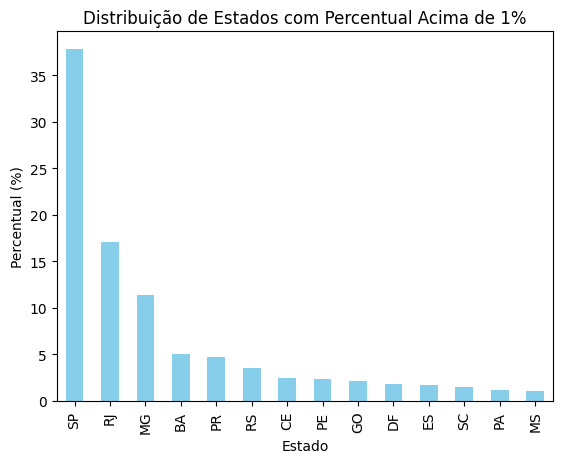

In [23]:
# No histograma abaixo

# Filtrar os estados com mais de 1% de participação
percentual_acima_1 = percentual[percentual > 1]

# Gerar o histograma
percentual_acima_1.plot(kind='bar', color='skyblue')

# Configurar título e rótulos
plt.title('Distribuição de Estados com Percentual Acima de 1%')
plt.xlabel('Estado')
plt.ylabel('Percentual (%)')

# Exibir o gráfico
plt.show()


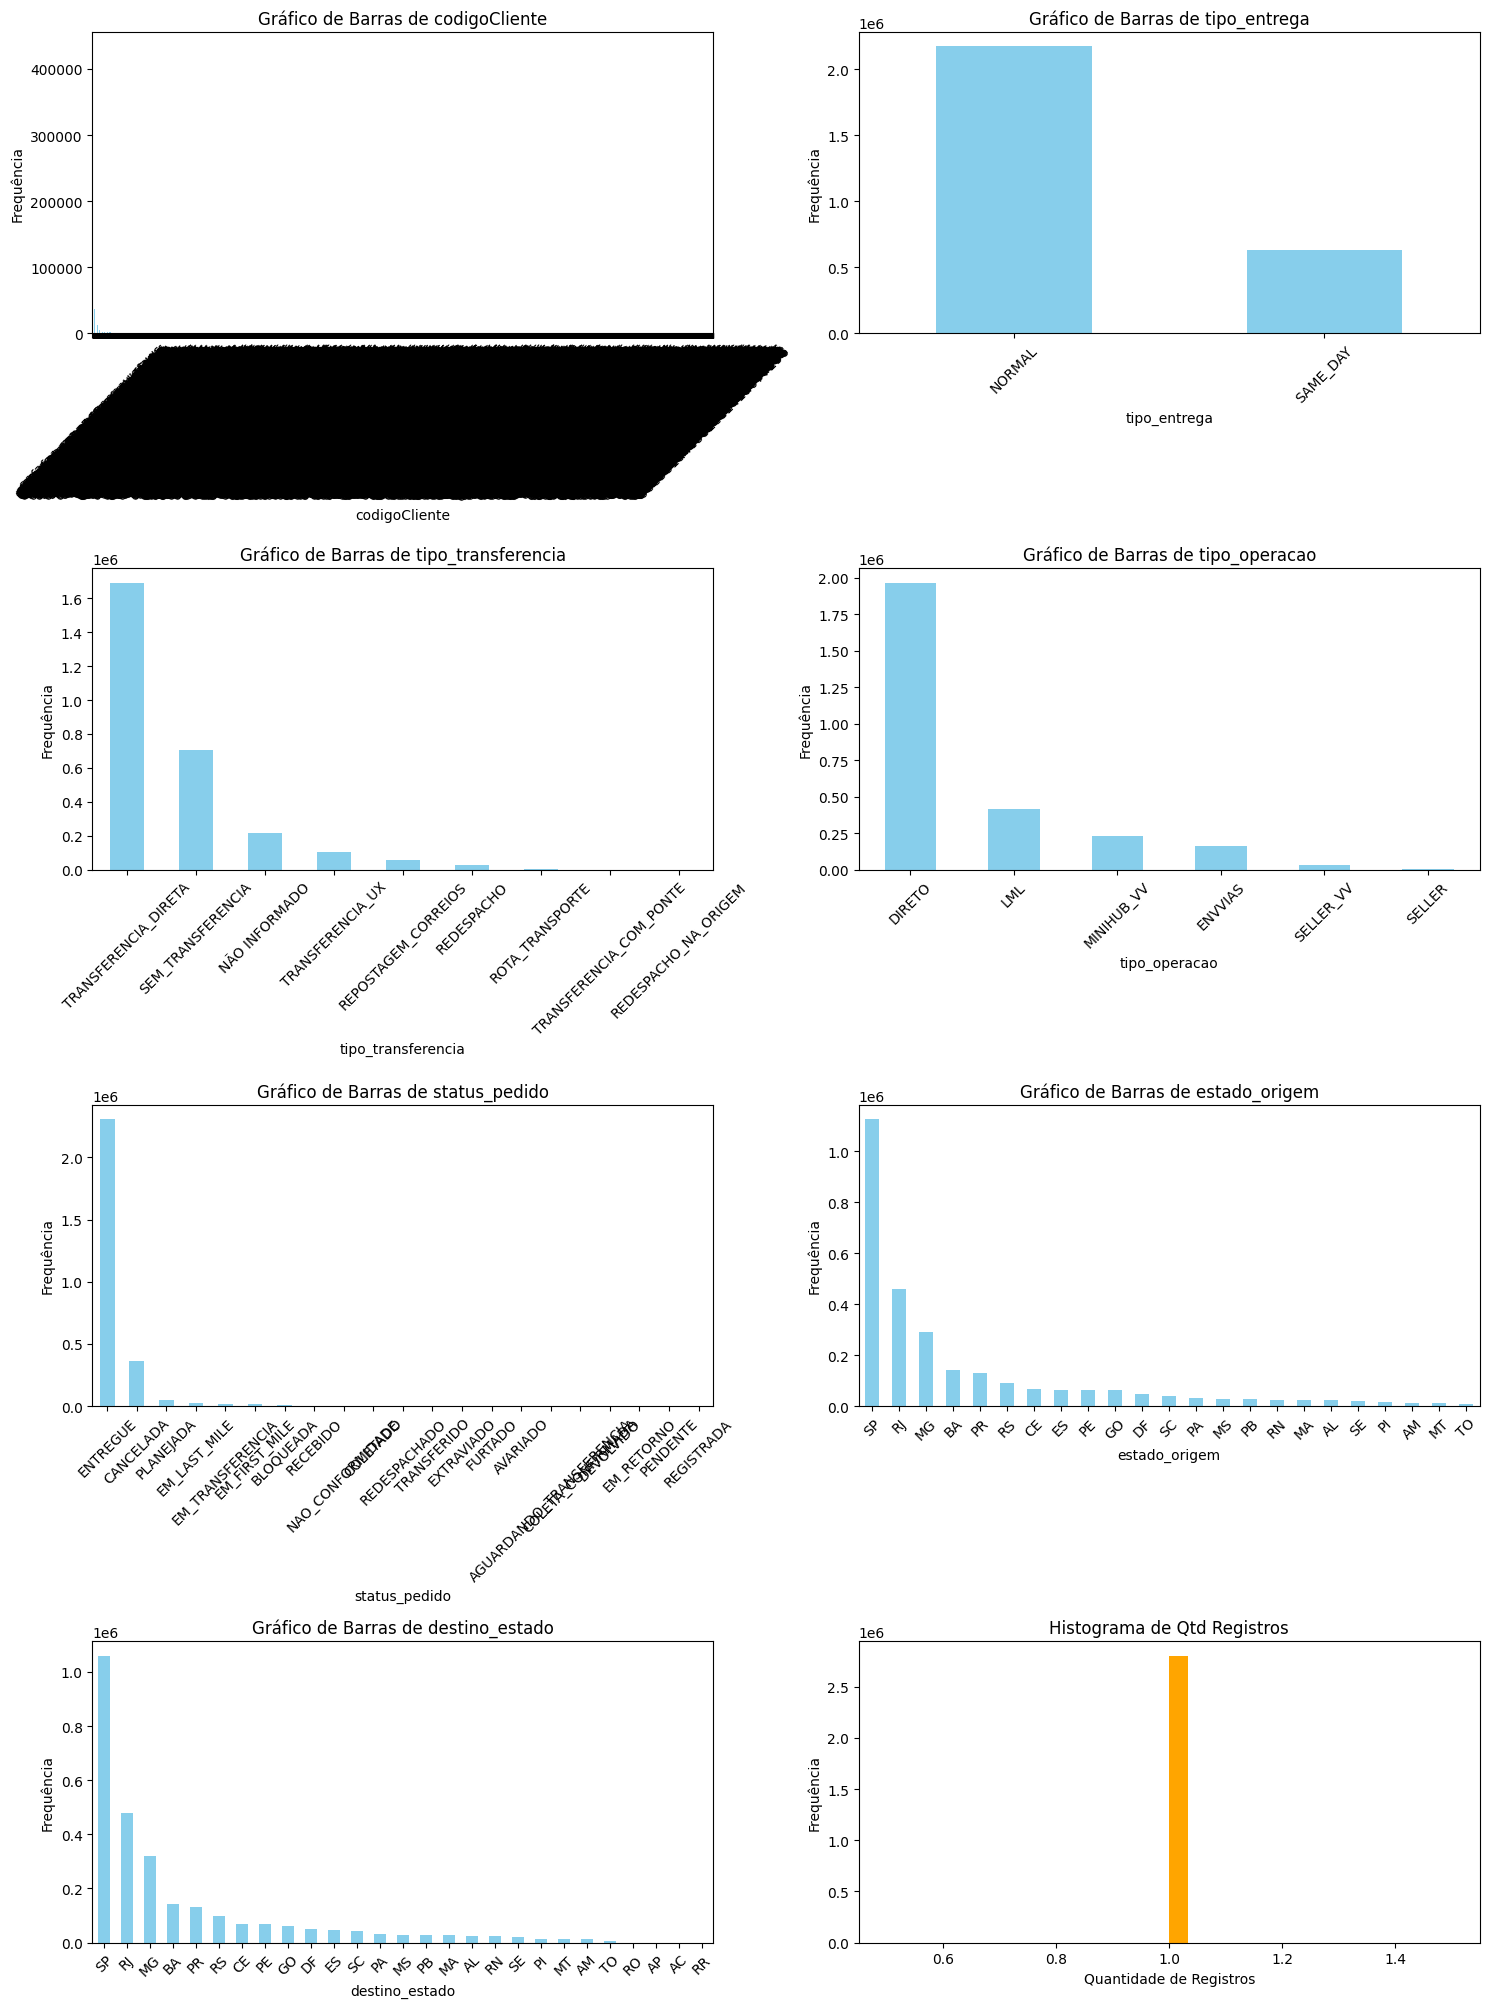

In [24]:
# Histogramas
df_analise = df_pandas
# criando coluna especial de contagem unica
df_pandas['qtd_registros'] = 1
df_pandas['qtd_registros'] = df_pandas['qtd_registros'].astype('int64')

# aplicando em analises
df_analise.loc[:, 'qtd_registros'] = df_pandas['qtd_registros']

# Definindo as colunas categóricas
colunas_categoricas = ['codigoCliente', 'tipo_entrega', 'tipo_transferencia', 'tipo_operacao',
                       'status_pedido', 'estado_origem', 'destino_estado']

# Número de colunas e linhas no painel
n_colunas = 2
n_linhas = (len(colunas_categoricas) + 1) // n_colunas + (len(colunas_categoricas) % n_colunas > 0)

# Criando a figura com subplots
fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(15, 5 * n_linhas))
axes = axes.flatten()

# Gerando os gráficos de barras para cada coluna categórica
for i, coluna in enumerate(colunas_categoricas):
    df_analise[coluna].value_counts().plot(kind='bar', ax=axes[i], color='skyblue')
    axes[i].set_title(f'Gráfico de Barras de {coluna}')
    axes[i].set_xlabel(coluna)
    axes[i].set_ylabel('Frequência')
    axes[i].tick_params(axis='x', rotation=45)

# Adicionando o histograma da coluna 'qtd_registros'
df_analise['qtd_registros'].plot(kind='hist', bins=30, ax=axes[len(colunas_categoricas)], color='orange')
axes[len(colunas_categoricas)].set_title('Histograma de Qtd Registros')
axes[len(colunas_categoricas)].set_xlabel('Quantidade de Registros')
axes[len(colunas_categoricas)].set_ylabel('Frequência')

# Remover gráficos vazios (se houver número de colunas ímpar)
for j in range(len(colunas_categoricas) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Verificando a distribuição de classes e balanceamento

In [25]:
# Criando um dicionário para armazenar as distribuições
distribuicoes = {}

# Verificando a distribuição de frequência das classes
for coluna in ['tipo_entrega', 'tipo_transferencia', 'tipo_operacao',
               'status_pedido', 'estado_origem', 'destino_estado']:
    distribuicoes[coluna] = df_analise[coluna].value_counts()

# Exibindo as distribuições
for coluna, freq in distribuicoes.items():
    print(f"Distribuição de Frequência para {coluna}:")
    print(freq)
    print("\n")


Distribuição de Frequência para tipo_entrega:
tipo_entrega
NORMAL      2173019
SAME_DAY     632940
Name: count, dtype: int64


Distribuição de Frequência para tipo_transferencia:
tipo_transferencia
TRANSFERENCIA_DIRETA       1692260
SEM_TRANSFERENCIA           706516
NÃO INFORMADO               214999
TRANSFERENCIA_UX            104994
REPOSTAGEM_CORREIOS          54502
REDESPACHO                   25165
ROTA_TRANSPORTE               6835
TRANSFERENCIA_COM_PONTE        663
REDESPACHO_NA_ORIGEM            25
Name: count, dtype: int64


Distribuição de Frequência para tipo_operacao:
tipo_operacao
DIRETO        1966049
LML            413504
MINIHUB_VV     231721
ENVVIAS        159230
SELLER_VV       32847
SELLER           2608
Name: count, dtype: int64


Distribuição de Frequência para status_pedido:
status_pedido
ENTREGUE                    2306927
CANCELADA                    366610
PLANEJADA                     52214
EM_LAST_MILE                  27023
EM_TRANSFERENCIA              195

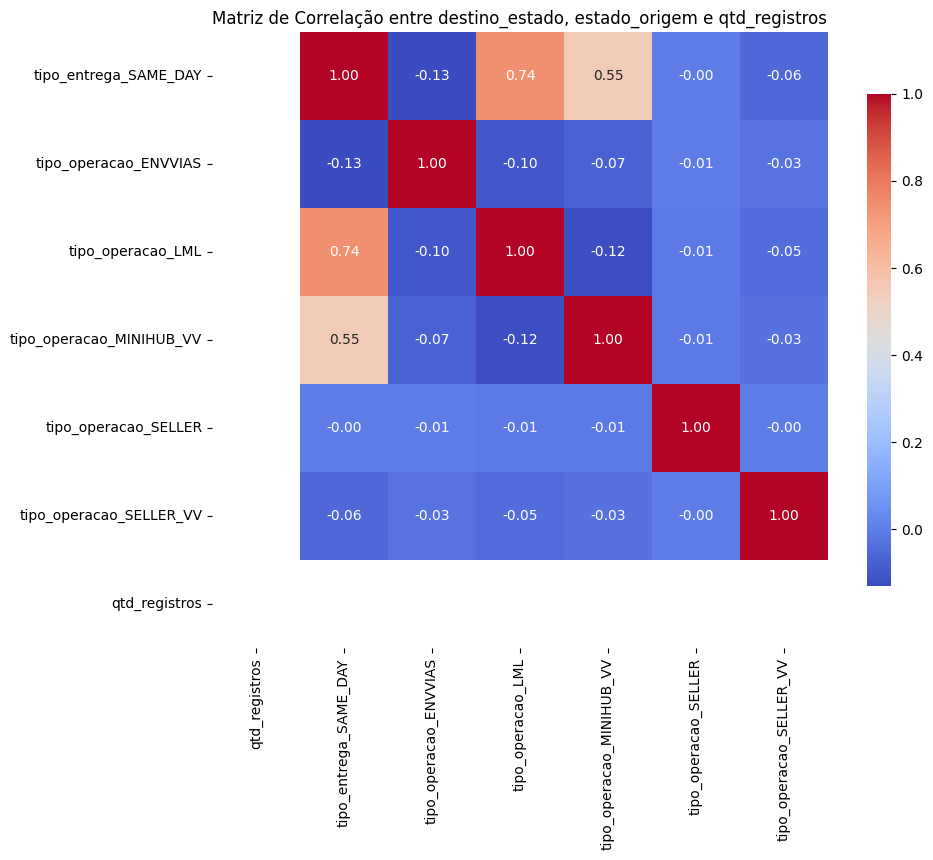

In [26]:
# Codificar as colunas categóricas usando one-hot encoding
df_encoded = pd.get_dummies(df_analise[['tipo_entrega','tipo_operacao']], drop_first=True)

# Adicionar a coluna 'qtd_registros' ao DataFrame codificado
df_encoded['qtd_registros'] = df_analise['qtd_registros']

# Calcular a matriz de correlação
correlation_matrix = df_encoded.corr()

# Selecionar apenas as colunas de interesse
correlation_subset = correlation_matrix.loc[:, ['qtd_registros'] + list(df_encoded.columns[:-1])]

# Configurar o tamanho do gráfico
plt.figure(figsize=(10, 8))

# Criar um mapa de calor da matriz de correlação
sns.heatmap(correlation_subset, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={"shrink": .8})

# Configurar o título
plt.title('Matriz de Correlação entre destino_estado, estado_origem e qtd_registros')

# Mostrar o gráfico
plt.show()

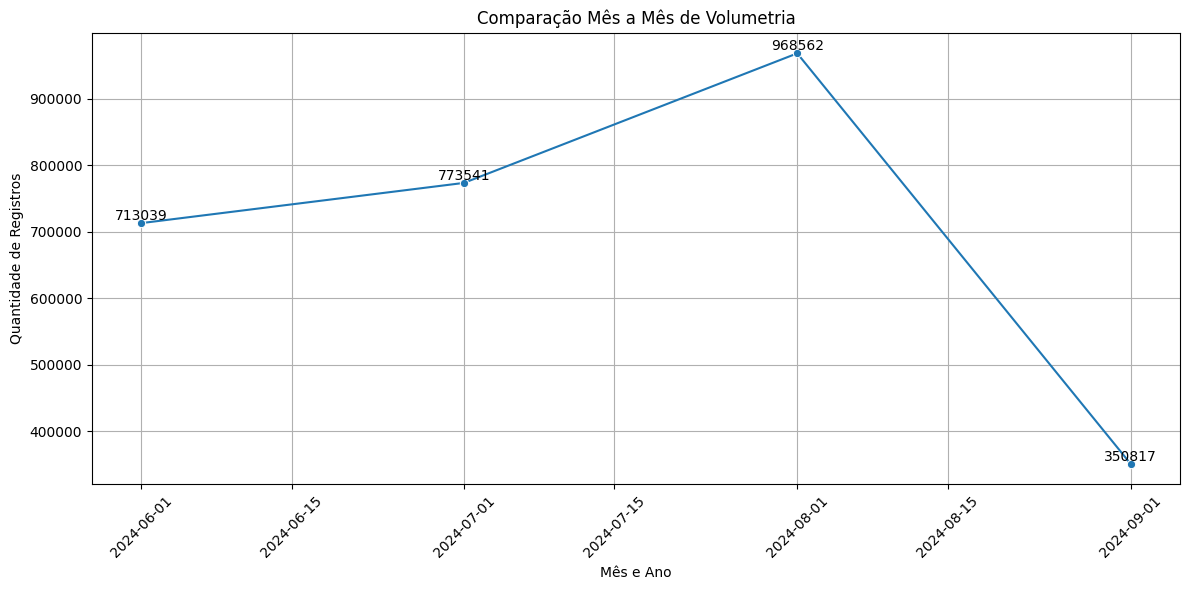

In [27]:
# ATENÇÃO PARA QUE a 'data_criacao' está no formato datetime
df_analise.loc[:, 'data_criacao'] = pd.to_datetime(df_analise['data_criacao'])

# Criar uma coluna para Mês e Ano
df_analise.loc[:, 'Mes_Ano'] = df_analise['data_criacao'].dt.to_period('M')

# Agrupar os dados por Mês e Ano, somando 'qtd_registros'
volumetria_mensal = df_analise.groupby('Mes_Ano')['qtd_registros'].sum().reset_index()

# Converter 'Mes_Ano' de volta para um formato de data para melhor visualização
volumetria_mensal['Mes_Ano'] = volumetria_mensal['Mes_Ano'].dt.to_timestamp()

# Configurar o tamanho do gráfico
plt.figure(figsize=(12, 6))

# Criar um gráfico de linhas
sns.lineplot(data=volumetria_mensal, x='Mes_Ano', y='qtd_registros', marker='o')

# Adicionar anotações para cada ponto
for i, row in volumetria_mensal.iterrows():
    plt.text(row['Mes_Ano'], row['qtd_registros'], int(row['qtd_registros']),
             ha='center', va='bottom')

# Adicionar rótulos e título na nossa análise
plt.title('Comparação Mês a Mês de Volumetria')
plt.xlabel('Mês e Ano')
plt.ylabel('Quantidade de Registros')
plt.xticks(rotation=45)
plt.grid()

# Mostrar o gráfico
plt.tight_layout()
plt.show()

In [28]:
type(df_analise)

pandas.core.frame.DataFrame

# Conclusão no último gráfico

Existe uma forte tendência na queda de entregas, deixando para uma segunda análise comparando com a volumetria no ano de 2023

# Análise Regressiva


In [29]:
# CRIANDO DATAFRAME PANDAS A PARTIR DA ORIGEM
df_regressao = df_pandas


df_regressao.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2805959 entries, 630306 to 2084309
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   id_pedido              object        
 1   codigoCliente          category      
 2   data_criacao           datetime64[ns]
 3   ultima_atualizacao     datetime64[us]
 4   data_planejada         datetime64[us]
 5   data_previsao_entrega  datetime64[us]
 6   prazo_maximo_entrega   datetime64[us]
 7   tipo_entrega           object        
 8   tipo_transferencia     object        
 9   tipo_operacao          object        
 10  status_pedido          object        
 11  valor_nota             float64       
 12  estado_origem          object        
 13  destino_estado         object        
 14  dataGeracao            datetime64[ns]
 15  Ano                    int32         
 16  Mes                    int32         
 17  Dia                    int32         
 18  qtd_registros         

# Análise de Regressão

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def train_and_evaluate_model(agg_data):
    """Treina e avalia um modelo de regressão linear usando os dados agregados."""
    # Separar as variáveis independentes (X) e dependentes (y)
    X = agg_data['ano_dia_criacao'].map(lambda date: date.toordinal()).values.reshape(-1, 1)  # Converter data para ordinal
    y = agg_data['quantidade']

    # Dividir os dados em treino e teste
    if len(agg_data) > 1:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

        # Treinar o modelo de regressão linear
        model = LinearRegression()
        model.fit(X_train, y_train)

        # Fazer previsões no conjunto de teste
        y_pred = model.predict(X_test)

        # Avaliar o modelo
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print("\nAvaliação do modelo de regressão linear:")
        print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
        print(f"Coeficiente de Determinação (R^2): {r2:.2f}")

        # Exibir coeficientes do modelo
        print("\nCoeficientes do modelo:")
        print(f"Intercepto: {model.intercept_}")
        print(f"Coeficiente: {model.coef_[0]}")

        return model
    else:
        print("Dados insuficientes para dividir em treino e teste. Verifique sua base de dados.")
        return None

# TRAZENDO PARA OUTRO DATAFRAME PARA ANALISE DE REGRESSÃO
df_regressao = df_pandas

df_regressao["quantidade"] = 1  # Insere valores inteiros diretamente
df_regressao = df_regressao.astype({"quantidade": "int32"})

# Criar uma nova coluna representando o dia de criação do pedido
if 'data_criacao' in df_regressao.columns:
    df_regressao['ano_dia_criacao'] = df_regressao['data_criacao'].dt.to_period('D')

    # Agregar os dados: contar a quantidade de pedidos por dia
    agg_data = df_regressao.groupby('ano_dia_criacao').size().reset_index(name='quantidade')

    # Verificar a quantidade de registros no DataFrame agregado
    print(f"Quantidade de registros após agregação: {len(agg_data)}")

    if len(agg_data) < 10:
        print("Poucos registros após agregação. Considere verificar os dados ou ajustar a granularidade.")

    # Converter a coluna 'ano_dia_criacao' para datetime para facilitar a divisão
    agg_data['ano_dia_criacao'] = agg_data['ano_dia_criacao'].dt.to_timestamp()

    # Treinar e avaliar o modelo
    train_and_evaluate_model(agg_data)
else:
    print("A coluna 'data_criacao' está ausente no DataFrame. Verifique os dados.")


Quantidade de registros após agregação: 106

Avaliação do modelo de regressão linear:
Erro Quadrático Médio (MSE): 169687823.14
Coeficiente de Determinação (R^2): -1.59

Coeficientes do modelo:
Intercepto: -107557156.73271914
Coeficiente: 145.56507036549564
